# Algorithms

**Disclaimer: portions of the following text have been generated using github CoPilot. The provided information has been validated by expert review.** 

In `pyphysio`, signal processing steps are represented and implemented as modular, reusable algorithms.

This design allows for flexibility, extensibility, and efficient processing of physiological signals. Here's how it works:

---

### **1. Representation of Signal Processing Steps**
Signal processing steps are represented as subclasses of the `_Algorithm` base class. Each subclass implements a specific algorithm or processing step, such as filtering, feature extraction, or transformation. The `_Algorithm` class provides a standardized interface and workflow for applying these steps to signals.

---

### **2. The `_Algorithm` Base Class**
The `_Algorithm` class defines the structure and workflow for all signal processing steps. Key features include:

#### **Attributes**
- `_params`: A dictionary to store parameters for the algorithm.
- `required_dims`: A list of dimensions required by the algorithm (e.g., `time`, `channel`). For instance, simple filters require the dimension `time`, meaning that all datapoints will be used.
- `name`: The name of the algorithm, derived from the class name.

#### **Main Methods**
- **`algorithm(cls, signal)`**: An abstract method that must be implemented by subclasses. It defines the core logic of the algorithm.
- **`__call__(self, signal_in, scheduler=scheduler, **kwargs)`**: The main entry point for applying the algorithm. It handles chunking, parallelization, and combining results.
---

### **3. Workflow for Signal Processing**
The `_Algorithm` class provides a standardized workflow for applying signal processing steps:

1. **Input Signal**: The input signal is an `xarray.DataArray` object, which may have multiple dimensions (e.g., time, channel, component, ...).
3. **Parallel Processing**: The `__call__` method internally uses `xarray.map_blocks` to apply the algorithm to enable parallel processing of signals using Dask if configured. The parallelization is performed across the dimensions that are NOT required by the algorithm (see attribute `required_dims`).
4. **Algorithm Execution**: The `algorithm` method is called on each chunk to perform the actual processing.
5. **Output Composition**: The results from all chunks are combined into a single `xarray.DataArray` object, preserving metadata and attributes from the input signal.

---

### **Summary**
`pyphysio` represents signal processing steps as subclasses of the `_Algorithm` base class. This design provides a standardized, extensible framework for implementing and applying algorithms to physiological signals. The use of `xarray` and Dask ensures compatibility with multidimensional data and efficient processing.

## Usage

A signal processing step is a computational function $F$ that operates on input data (a signal) to produce a result.

It is characterized by a set of parameters **p** which regulate its behavior.

A processing step is defined by creating a new instance of the algorithm, which is initialized with the given parameters:
```
processing_step = ph.BeatFromECG(parameters)
```
To execute the processing step we need to give as input an instance of the class `Signal`:
```
output = processing_step(input)
```

In [ ]:
# import packages
import numpy as np
import matplotlib.pyplot as plt

%matplotlib ipympl

In [ ]:
# import sample physiological data
from pyphysio import TestData
from pyphysio import create_signal

ecg_data = TestData.ecg()

# create two signals
fsamp = 2048

ecg = create_signal(data = ecg_data, sampling_freq = fsamp)

Using dask. Scheduler: threads
Please cite:
Bizzego et al. (2019) 'pyphysio: A physiological signal processing library for data science approaches in physiology', SoftwareX


### 2.1 Filters

The name *`Filters`* recalls the aim of this algorithms which is in general to increase the Signal/Noise ratio by filtering out the unwanted components in a signal (e.g high frequency noise).

In [2]:
# create a Filter
import pyphysio.filters as flt

lowpass_50 = flt.IIRFilter(fp=50, fs=75, ftype='ellip')

In [3]:
# check parameters
print(lowpass_50.get())

{'fp': 50, 'fs': 75, 'btype': 'bandpass', 'order': 3, 'loss': 0.1, 'att': 40, 'ftype': 'ellip', 'safe': True}


In [4]:
# apply a Filter
ecg_filtered = lowpass_50(ecg)

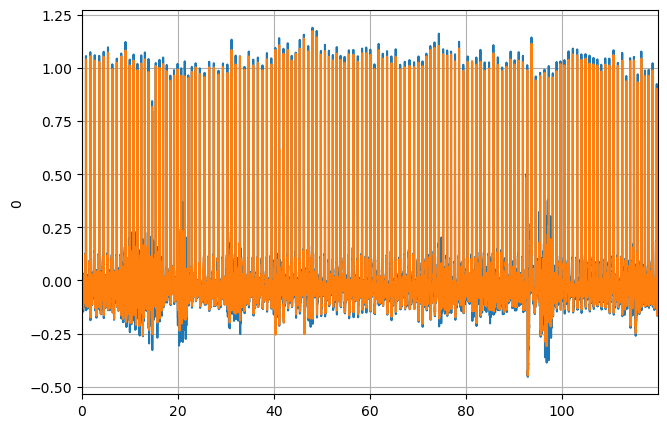

In [5]:
#plot
ecg.p.plot()
ecg_filtered.p.plot()

### 2.2 Specialized algorithms
Other algorithms aim at extracting the information of interest from specific types of physiological signals.

In [6]:
# create an Estimator
import pyphysio.specialized.heart as heart

ibi_ecg = heart.BeatFromECG()

Refactoring to be completed


In [7]:
# check parameters
ibi_ecg.get()

{'bpm_max': 120, 'delta': 0, 'k': 0.7}

In [8]:
# apply an Estimator
ibi = ibi_ecg(ecg)

In [9]:
ibi = ibi.p.process_na('remove') #ibi becomes an unevenly sampled signal

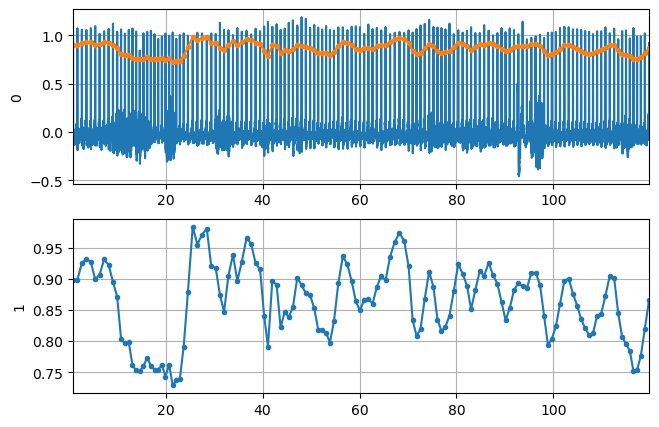

In [10]:
# plot
ax1 = plt.subplot(211)
ecg.p.plot()

plt.subplot(212, sharex=ax1)
ibi.p.plot()

### 2.3 Indicators

Indicators are algorithm which extract a metric (scalar value) from the input signal, for instance the average.

Three general types of indicators are provided in **`pyphysio`**:
* Time domain indicators: comprising simple statistical indicators and other metrics that can be computed on the signal values;
* Frequency domain indicators: metrics that are computed based on the Power Spectrum Density (PSD) of the signal;

In [11]:
# create an Indicator
import pyphysio.indicators.timedomain as td_ind

mean = td_ind.Mean()

In [12]:
# apply an Indicator
mean_ibi = mean(ibi)
print(mean_ibi)

<xarray.DataArray 'signal_BeatFromECG_Mean' (time: 1)> Size: 8B
array([0.86194989])
Coordinates:
  * time     (time) float64 8B 0.8491
Attributes:
    sampling_freq:  unevenly
    start_time:     0.0


In [13]:
import pyphysio.indicators.frequencydomain as fd_ind

HF = fd_ind.PowerInBand(freq_min=0.15, freq_max=0.4, method = 'period')

In [14]:
ibi_ = ibi.p.resample(4) #resampling is needed to compute the Power Spectrum Density
HF_ = HF(ibi_) 
print(HF_)

<xarray.DataArray 'signal_BeatFromECG_PowerInBand' (time: 1)> Size: 8B
array([0.00119464])
Coordinates:
  * time     (time) float64 8B 0.8491
Attributes:
    sampling_freq:  4
    start_time:     0.0


#### 2.3.4 Segmentation and Windowing

`pyphysio` provides segmentation mechanisms to divide a signal into specified segments and automatically compute indicators on each segment.

The `_Segmenter` class provides the framework for creating segments. It defines the general workflow for segmentation and is extended by specific segmenter classes.

- **Attributes**:
  - `timeline`: A signal used to define the timeline for segmentation, or to automatically label the segments (e.g. a signal representing different experimental phases)
  - `reference`: The signal to be segmented.
  - `drop_cut` and `drop_mixed`: To control the segmentation behavior.

There are 4 different segmenter classes that extend `_Segmenter`:
- **`FixedSegments`**: Divides the signal into fixed-width segments based on a specified `step` and `width`.
- **`CustomSegments`**: Creates segments based on custom start and end times.
- **`LabelSegments`**: Segments the signal based on changes in the values of the timeline signal.
- **`RandomFixedSegments`**: Generates random fixed-width segments.

The `fmap` function is used to apply a set of algorithms (e.g., indicators) to each segment of a signal generated by a segmenter. It iteratively processes each segment and computes the desired indicators.

Finally, the `indicators2df` function can be used to aggregate the indicators computed for each portion (and channel, and component) into a `pandas.DataFrame`.

In [15]:
from pyphysio.segmenters import FixedSegments, CustomSegments, LabelSegments, RandomFixedSegments, fmap, indicators2df

In [16]:
# create fake experimental timeline
label = np.zeros(1200)
label[300:600] = 1 #stimulus 1
label[900:1200] = 2 # stimulus 2

label = create_signal(label, sampling_freq = 10)

#define indicators to compute
algorithms = [td_ind.Mean(), td_ind.StDev()]

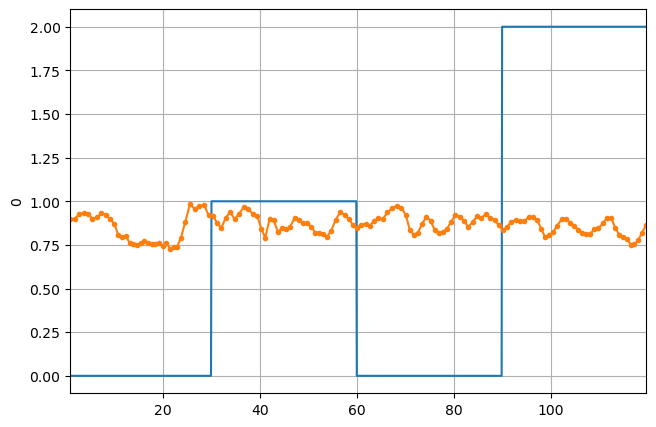

In [17]:
label.p.plot()
ibi.p.plot()

<xarray.DataArray 'label' (time: 16)> Size: 128B
array([0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 2., 2., 2., 2.])
Coordinates:
  * time     (time) float64 128B 0.8491 6.34 11.56 16.16 ... 96.37 101.4 106.6
    label    (time) float64 128B 0.0 0.0 0.0 0.0 1.0 1.0 ... 0.0 2.0 2.0 2.0 2.0


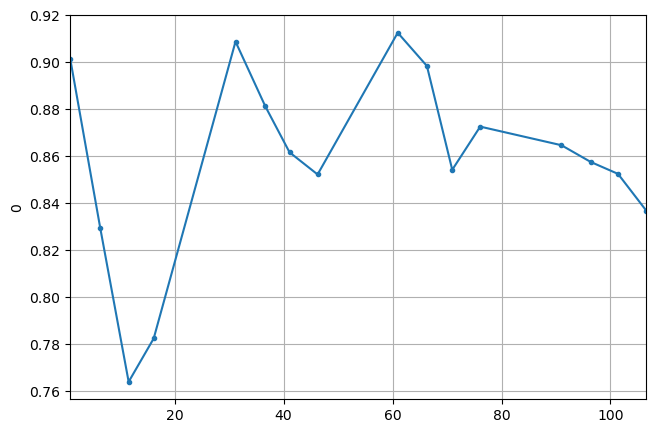

In [18]:
fixed_segmenter = FixedSegments(step=5, width=10, timeline=label)
results = fmap(fixed_segmenter, algorithms, ibi)

results['signal_BeatFromECG_Mean'].p.plot()
print(results['label'])

In [19]:
results_df = indicators2df(results)
print(results_df)

{'signal_BeatFromECG_Mean':           time  label  signal_BeatFromECG_Mean  component  channel
0     0.849121    0.0                 0.901367          1        1
1     6.340332    0.0                 0.829508          1        1
2    11.562988    0.0                 0.763860          1        1
3    16.160645    0.0                 0.782339          1        1
4    31.178711    1.0                 0.908825          1        1
5    36.662109    1.0                 0.881170          1        1
6    41.092773    1.0                 0.861654          1        1
7    46.244141    1.0                 0.852214          1        1
8    60.953125    0.0                 0.912598          1        1
9    66.308105    0.0                 0.898438          1        1
10   70.958984    0.0                 0.854207          1        1
11   76.089844    0.0                 0.872599          1        1
12   91.000977    2.0                 0.864665          1        1
13   96.370605    2.0             

**Examples with other Segmenters**

<xarray.DataArray 'label' (time: 4)> Size: 32B
array([0., 1., 0., 2.])
Coordinates:
  * time     (time) float64 32B 0.8491 30.3 60.09 90.15
    label    (time) float64 32B 0.0 1.0 0.0 2.0


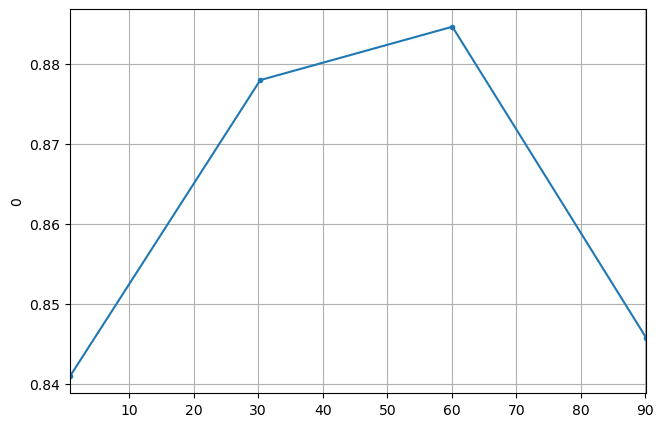

In [20]:
label_segmenter = LabelSegments(timeline=label)
results = fmap(label_segmenter, algorithms, ibi)

results['signal_BeatFromECG_Mean'].p.plot()
print(results['label'])

<xarray.DataArray 'label' (time: 3)> Size: 24B
array([3., 4., 5.])
Coordinates:
  * time     (time) float64 24B 2.674 45.39 70.12
    label    (time) float64 24B 3.0 4.0 5.0


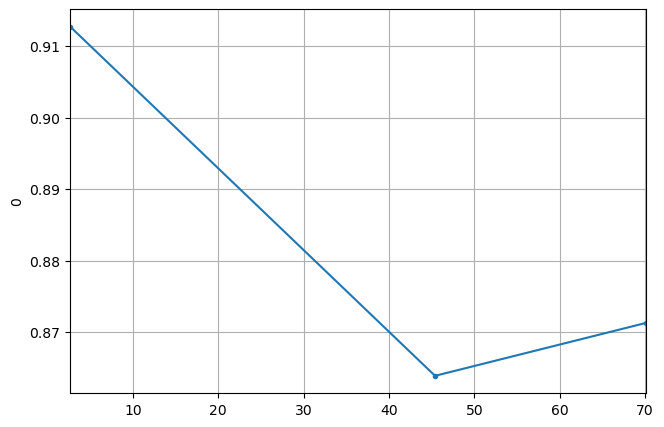

In [21]:
custom_segmenter = CustomSegments(begins = [2, 45, 70], ends = [10, 60, 100], labels = [3, 4, 5])
results = fmap(custom_segmenter, algorithms, ibi)

results['signal_BeatFromECG_Mean'].p.plot()
print(results['label'])

#### 2.3.3 Signal Quality Indicators

Signal Quality Indicators (SQIs) are a special category of indicators, to assess the quality of physiological signals.pecific to signal quality assessment.
Each SQI requires the `threshold` parameter which should be a list of two elements with the minimum and maximum value the SQI is expected to assume in case of a signal with good quality.

SQIs return both the computed indicator value and an additional dimension (`is_good`) to indicating whether the value falls within the range specified by the parameter `threshold`.

In [22]:
from pyphysio.sqi import Kurtosis
kurtosis = Kurtosis(threshold = [0, 3])

kurtosis_ecg = kurtosis(ecg)

print(kurtosis_ecg)

<xarray.DataArray 'signal_Kurtosis' (time: 1, is_good: 2)> Size: 16B
array([[21.31468806,  0.        ]])
Coordinates:
  * time     (time) int64 8B 0
  * is_good  (is_good) int64 16B 0 1
Attributes:
    sampling_freq:  2048.0
    start_time:     0.0


### 2.5 Utils

This is a collection of useful algorithms that can be used for signal processing. 

These algorithms might return scalar values or numpy arrays.

In [23]:
# create a Tool
import pyphysio.utils as utils

compute_psd = utils.PSD(method='welch', interp_freq = 4)

In [24]:
# check parameters
compute_psd.get()

{'method': 'welch',
 'nfft': 2048,
 'window': 'hamming',
 'min_order': 10,
 'max_order': 30,
 'remove_mean': True,
 'scaling': 'density',
 'interp_freq': 4}

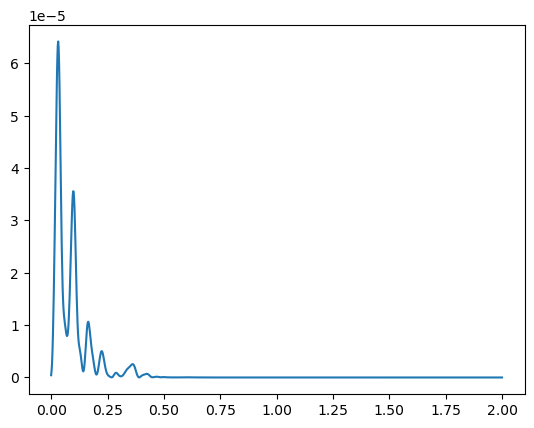

In [25]:
# apply a Tool
power = compute_psd(ibi.p.resample(4))

plt.plot(power.coords['freq'], power.p.get_values().ravel())
plt.show()